階層的クラスタリング

In [1]:
import pandas as pd

df = pd.read_excel("grade.xlsx")
df

,English,Mathematics
0,95,30
1,82,71
2,84,23
3,95,77
4,70,78


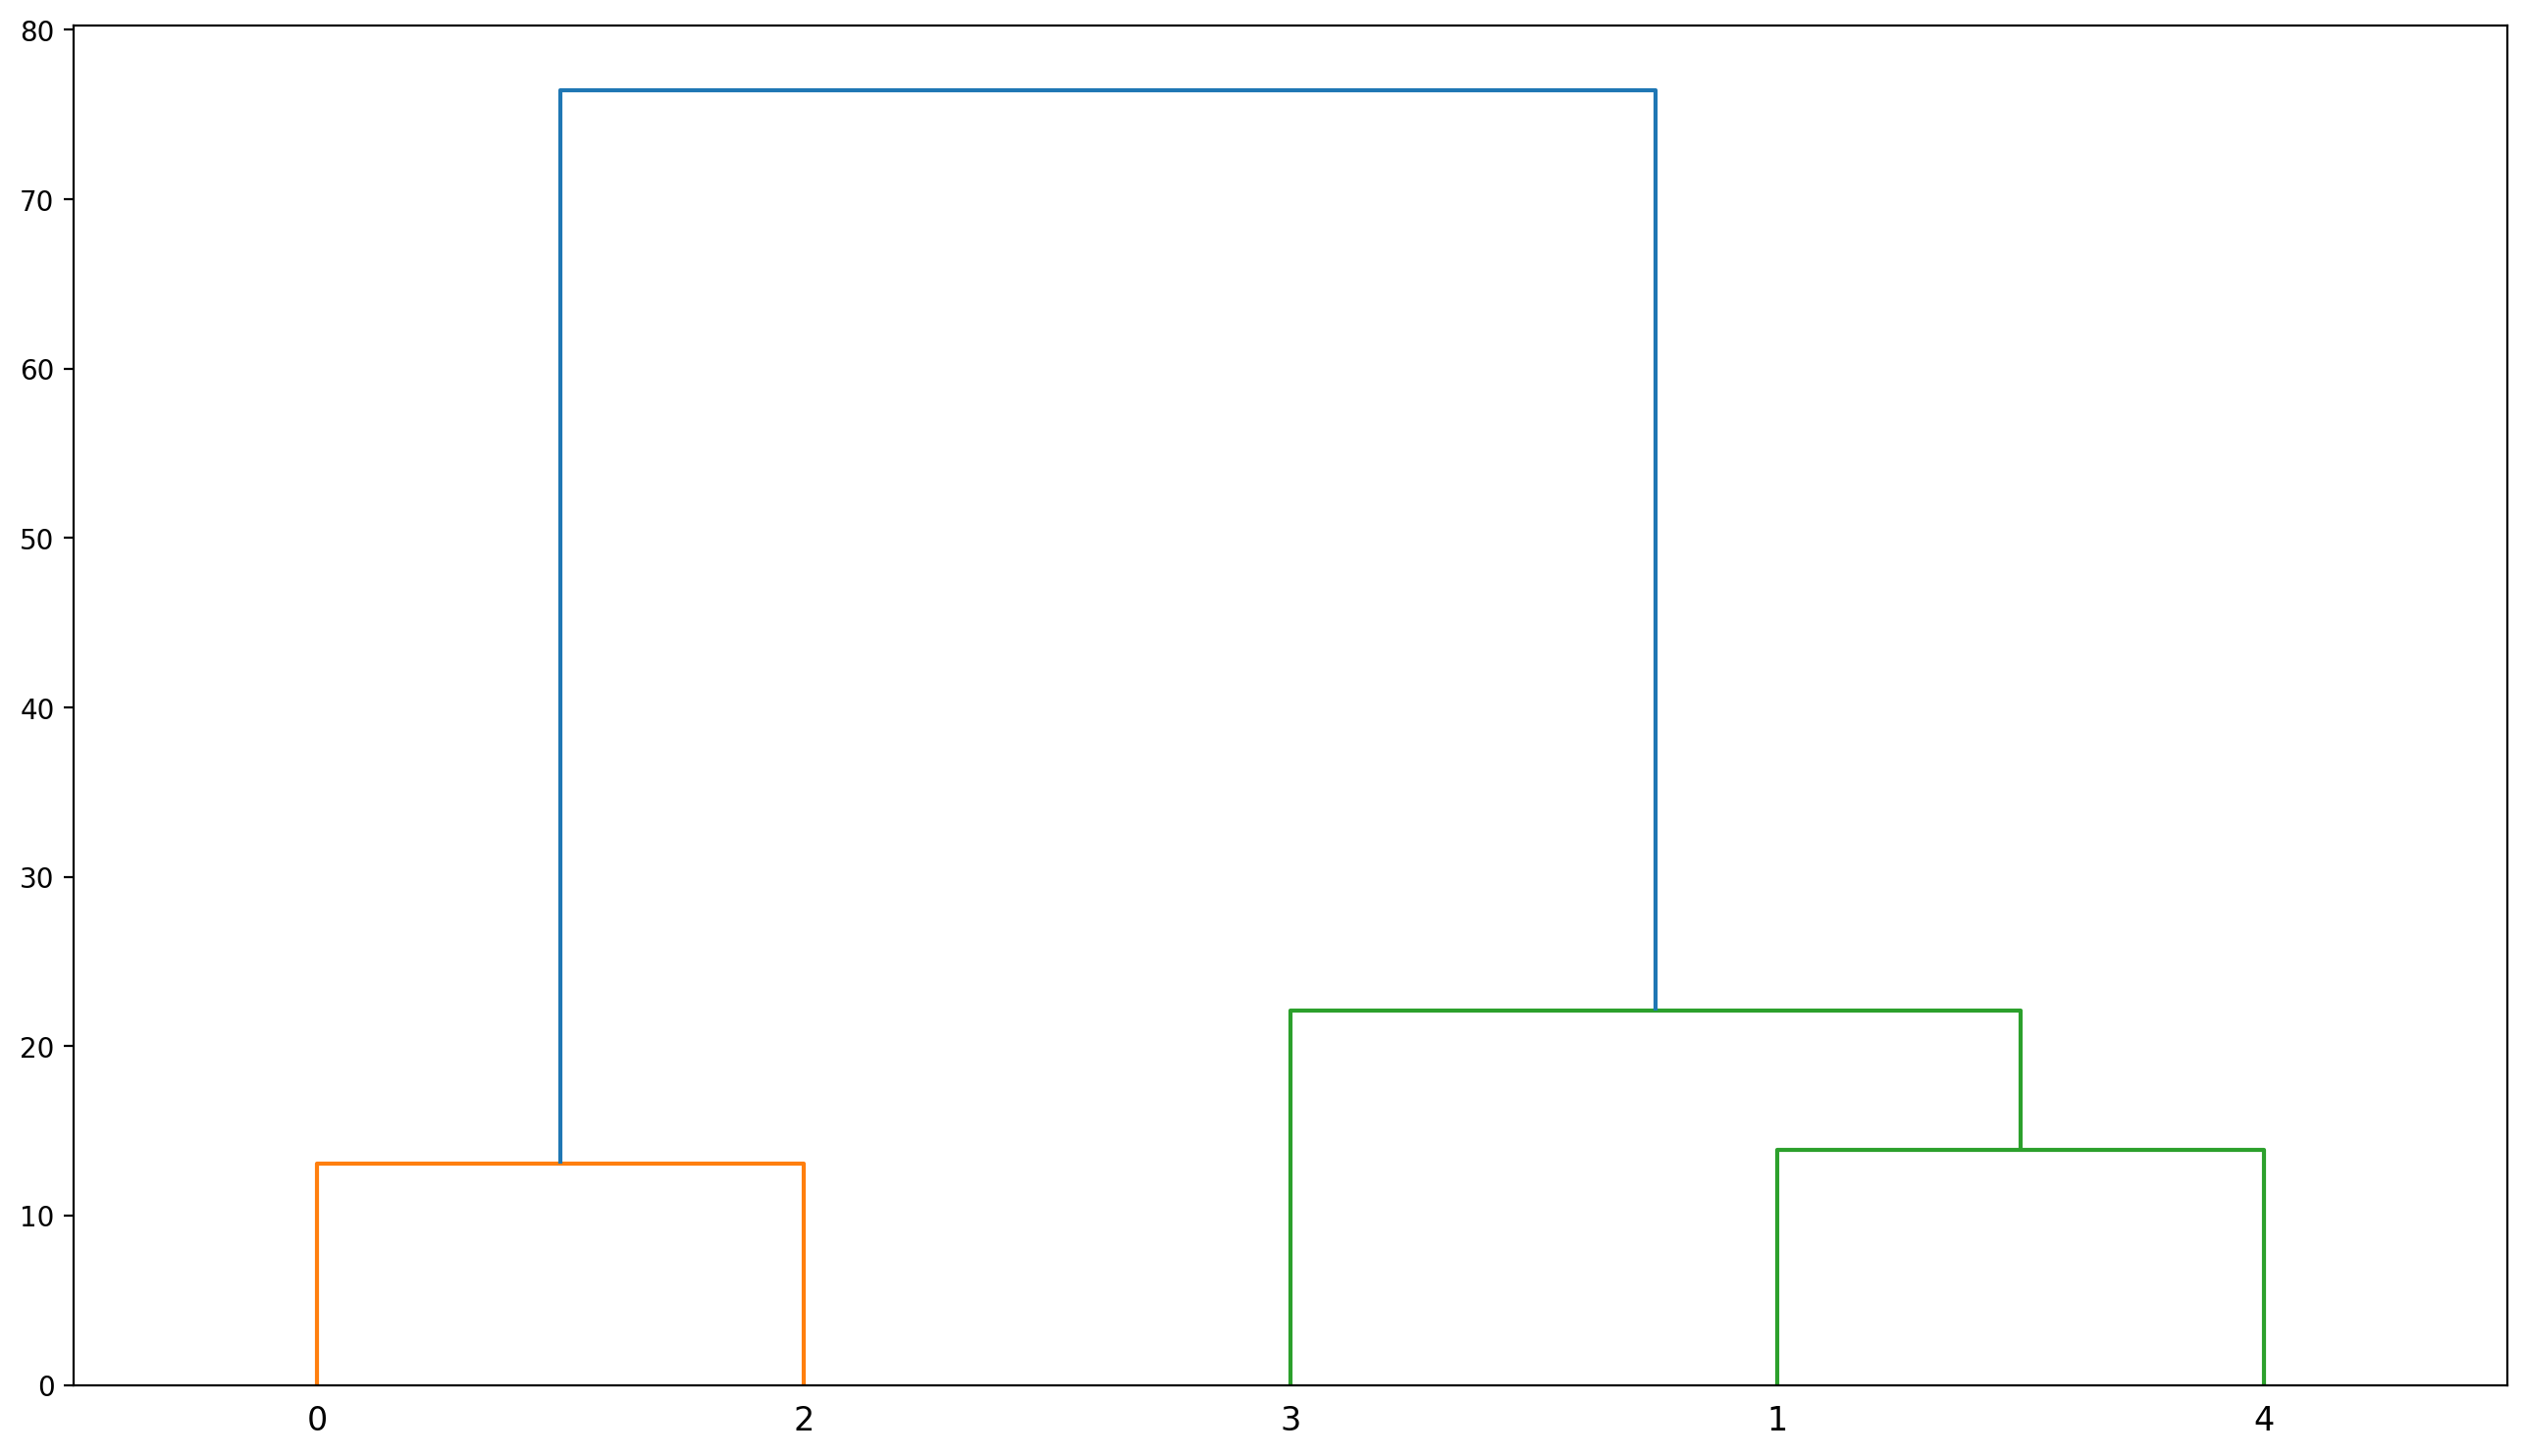

In [5]:
import matplotlib.pyplot as plt                                   # 可視化ライブラリ
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster # 数値解析ライブラリ

linkage_result = linkage(df, method='ward', metric='euclidean')   # ウォード法でクラスタ間の距離を計算
plt.figure(num=None, figsize=(16, 9), dpi=200, facecolor='w', edgecolor='k')
dendrogram(linkage_result, labels=df.index)
plt.show()

0と2の学生が似ていて、1と3と4が似ていると判断されていることが分かる

非階層的クラスタリング

In [11]:
df=pd.read_excel('wholesale_clean.xlsx')
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [12]:
from sklearn.cluster import KMeans
# 今回のクラスタリングに不要な情報は削除(購入履歴から顧客をクラスタリングするため)
df = df.drop("Channel", axis = 1)
df = df.drop("Region", axis = 1)

km = KMeans(n_clusters=4, random_state=0) # クラスタ数4での計算
result = km.fit_predict(df)
result

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 2, 0, 0, 1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 0, 0, 2, 3, 0, 0, 1, 2,
       1, 2, 2, 2, 1, 2, 1, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 1, 0, 1, 2, 2, 3,
       1, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 0, 1, 1, 1, 2,
       1, 2, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 3, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 2, 1, 0, 1, 1, 1, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1,
       3, 1, 1, 1, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 2, 2, 0, 1, 1, 2, 1, 1, 1, 2, 0, 2, 1, 1, 1, 1, 2, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 3, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 3, 3, 1, 1, 0, 1,
       1, 2, 2, 0, 2, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 3, 0, 3, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,

In [14]:
print('Distortion: %.2f'% km.inertia_) # Distortion(歪み)の確認

Distortion: 67458359184.53


k平均法では「クラスタ内誤差平方和(SSE)」を用いて歪みを数値化する

同じクラスのデータが近くに集まっていると歪みは小さくなり、逆に遠くまで広がっていると大きくなる

つまり、クラスタ数を増やすと歪みは小さくなるのだが、一定のラインを超えるとあまり減少しなくなる

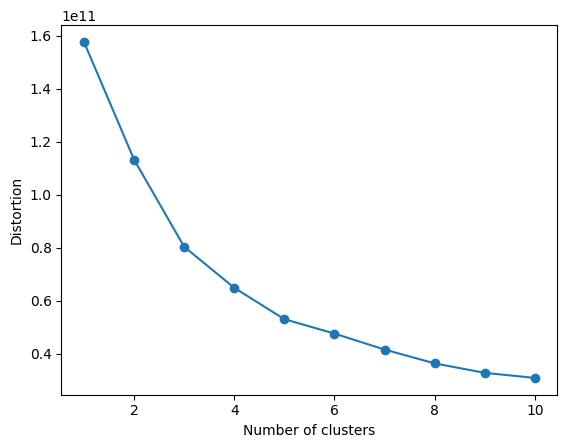

In [15]:
distortions = []
for i in range(1,11):
  km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=300, random_state=0)
  km.fit(df)
  distortions.append(km.inertia_)

plt.plot(range(1,11),distortions,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

クラスタ数を1から10に増やしながらクラスタリング結果の歪みを折れ線グラフで描画(エルボー法)

クラスタ数が4を超えると歪みの値があまり減らなくなっているので、今回はクラスタ数を4とする

In [17]:
df['cluster_id'] = result
df

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster_id
0,12669,9656,7561,214,2674,1338,1
1,7057,9810,9568,1762,3293,1776,1
2,6353,8808,7684,2405,3516,7844,1
3,13265,1196,4221,6404,507,1788,1
4,22615,5410,7198,3915,1777,5185,0
...,...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204,0
436,39228,1431,764,4510,93,2346,0
437,14531,15488,30243,437,14841,1867,2
438,10290,1981,2232,1038,168,2125,1


In [18]:
df['cluster_id'].value_counts()

,count
cluster_id,
1,266
0,112
2,49
3,13


In [19]:
grand_total = df.groupby('cluster_id').mean()
grand_total

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster_id,,,,,,
0,23241.151786,3835.375000,5097.910714,3683.401786,1135.741071,1639.598214
1,5804.086466,4035.251880,5465.849624,2397.266917,1919.808271,1061.150376
2,8149.836735,18715.857143,27756.591837,2034.714286,12523.020408,2282.142857
3,56453.307692,10026.230769,8739.000000,15518.076923,1258.230769,7170.538462


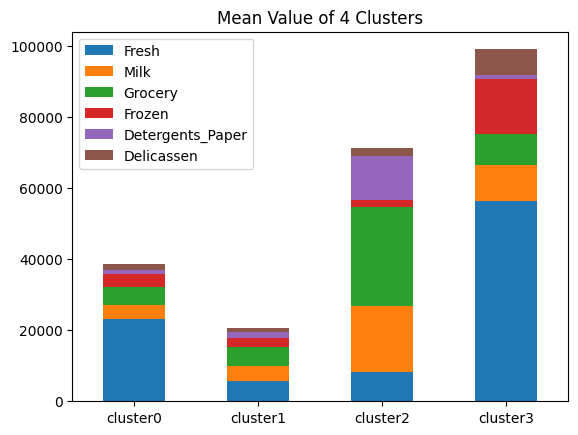

In [21]:
clusterinfo = pd.DataFrame()
for i in range(4):
  clusterinfo['cluster' + str(i)] = df[df['cluster_id'] == i].mean()
clusterinfo = clusterinfo.drop('cluster_id')

stacked_bar = clusterinfo.T.plot(kind='bar', stacked=True, title="Mean Value of 4 Clusters")
stacked_bar.set_xticklabels(stacked_bar.xaxis.get_majorticklabels(),rotation=0)
plt.show()

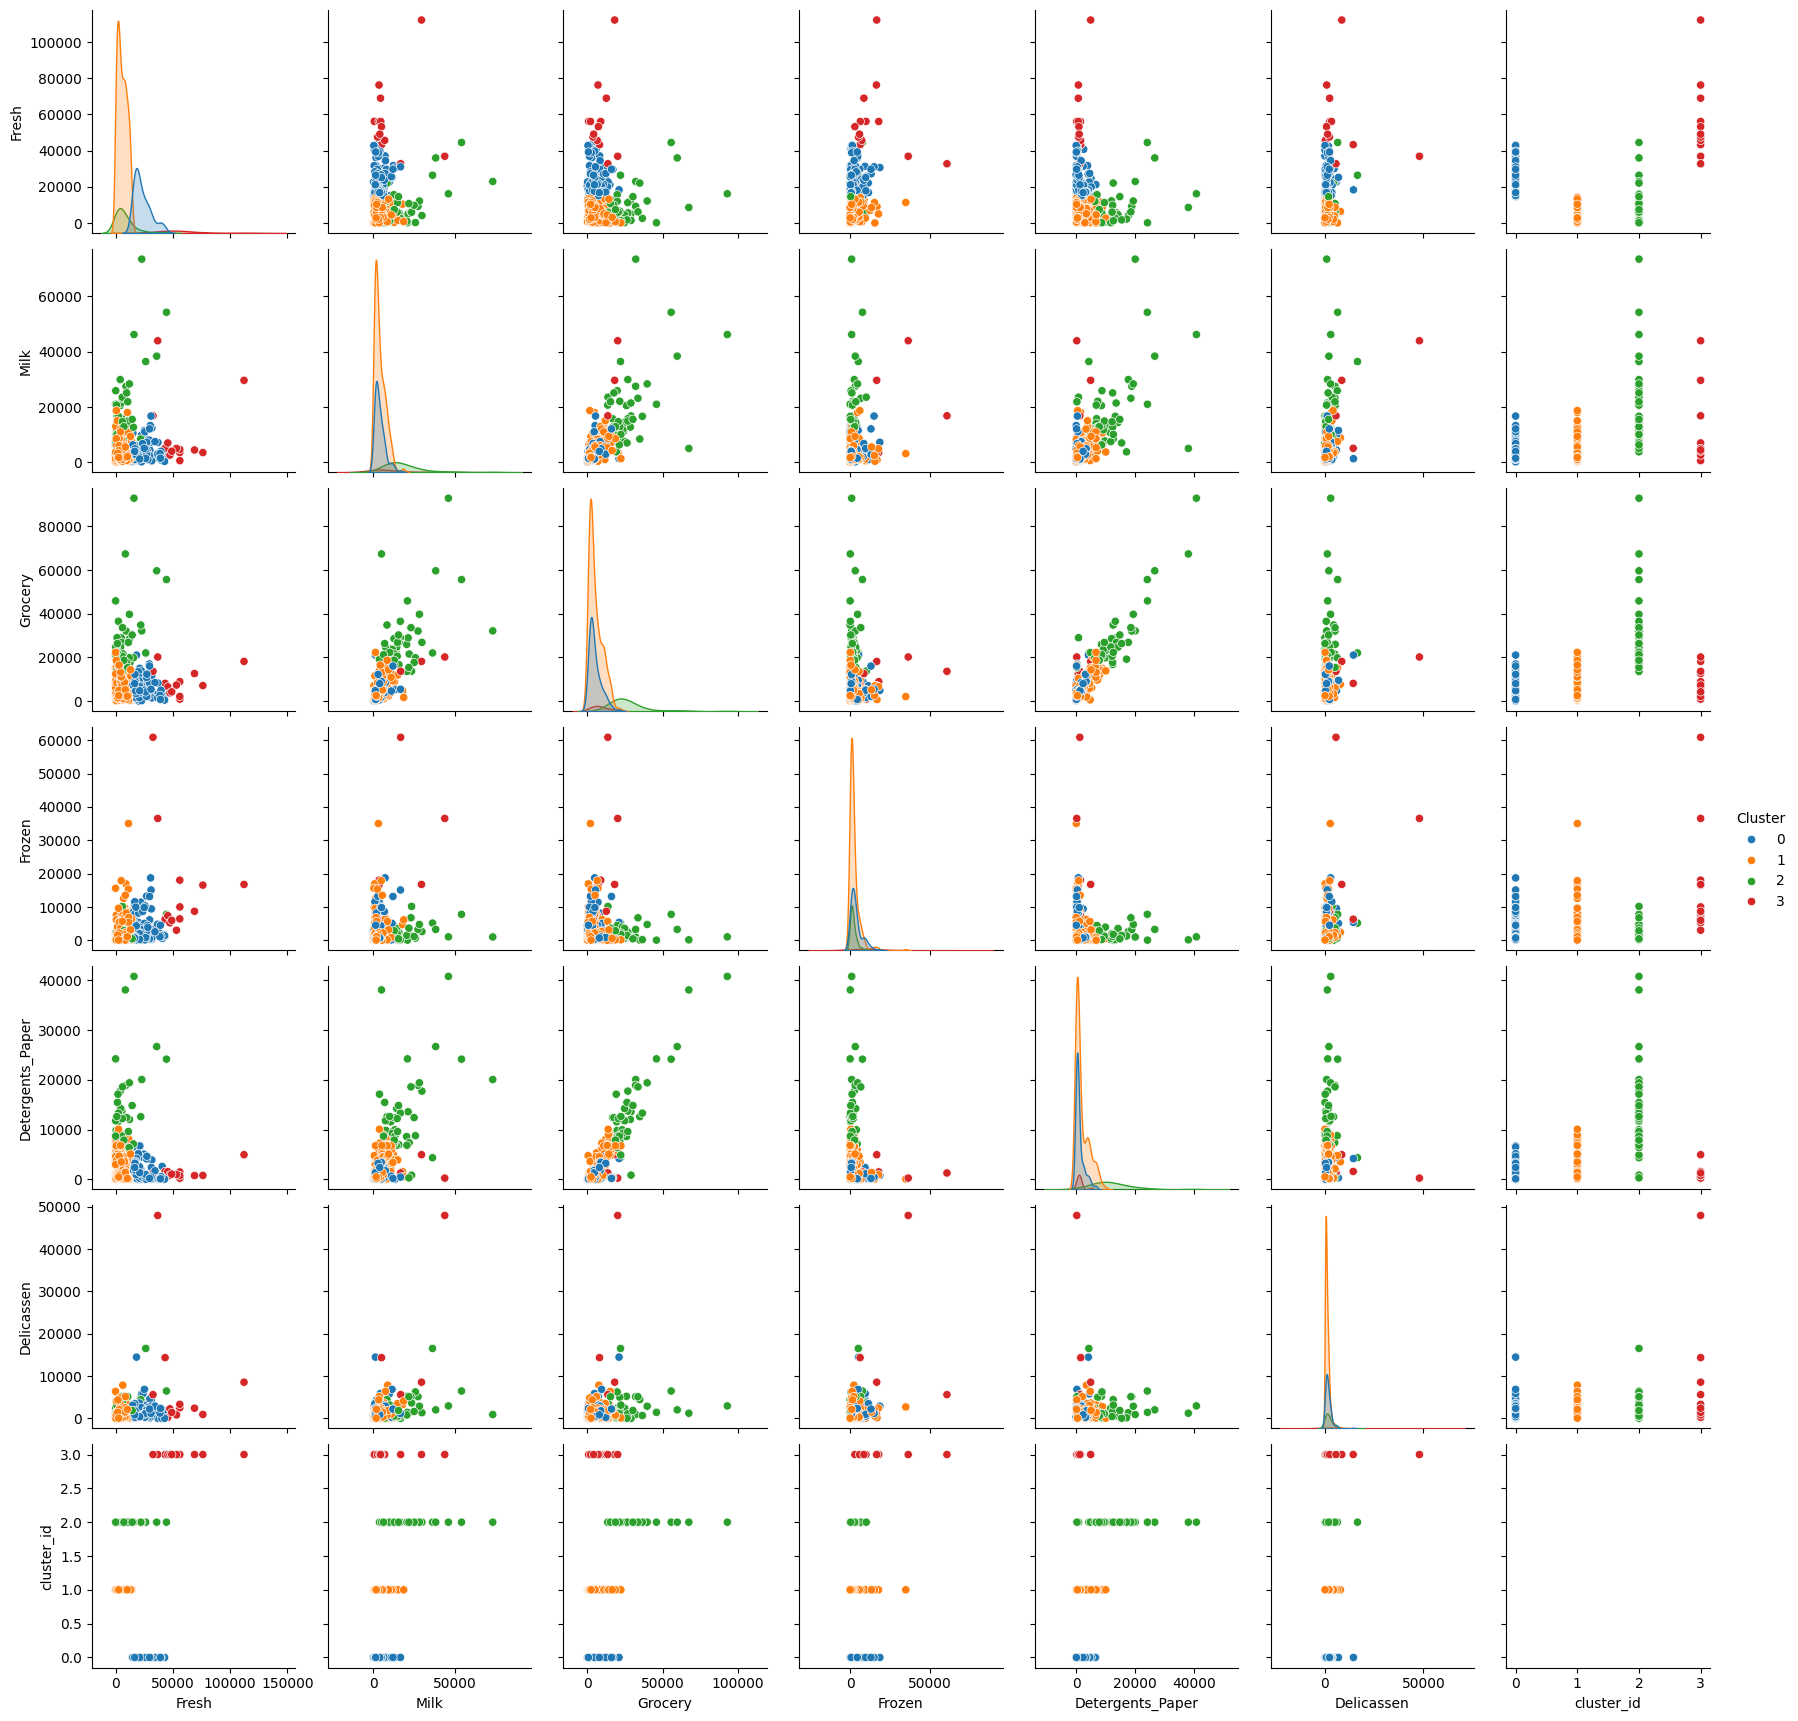

In [23]:
import seaborn as sns

# データフレームにクラスタリング結果を追加
df['Cluster'] = result

# ペアプロット
sns.pairplot(df, hue='Cluster', diag_kind='kde', palette='tab10')
plt.show()
